In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import os, torch
from datasets import load_dataset
torch.manual_seed(0)

In [2]:
# Downloads, converts and saves the DS
def prepare_ds(save_path):
  os.makedirs(os.path.dirname(save_path), exist_ok=True)

  # Use HF to download since much faster than UofT
  ds = load_dataset("uoft-cs/cifar10")

  def convert(split):
    # '[:]' to circumvent lazyness
    batch = ds[split].with_format("torch")[:]
    X = batch["img"].contiguous()
    return X, batch["label"]

  xtr, ytr = convert("train")
  xte, yte = convert("test")

  torch.save({"xtr":xtr,"ytr":ytr,"xte":xte,"yte":yte}, save_path)

In [3]:
PATH = '/content/drive/MyDrive/data/cifar10.pt'


def get_data(path=PATH):
    if not os.path.isfile(path):
        prepare_ds(path)
    return torch.load(path, weights_only=True)


d = get_data() # Approx 176.2MB
names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [4]:
# Validate data
import hashlib

# Verified size, shape, class counts
# Hash verified 15 Aug 2026
expected_hash = "ec6d2f649f1e0146023e9a0fa8400b17cd285750bb8b609d0bb306044c5c5a4e"

def tensor_digest(d):
    h = hashlib.sha256()
    for k in sorted(d):
        t = d[k]
        h.update(f"{k}{tuple(t.shape)}{t.dtype}".encode())
        h.update(t.contiguous().numpy().tobytes())
    return h.hexdigest()

assert tensor_digest(d) == expected_hash

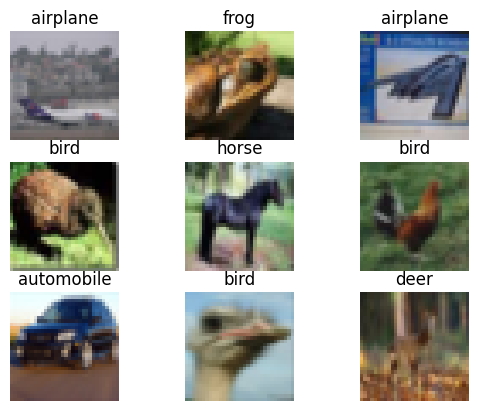

In [20]:
import matplotlib.pyplot as plt

# Visual check
figure, axis = plt.subplots(3,3)
for i, ax in enumerate(axis.flat):
  ax.imshow(d['xtr'][i].permute(1,2,0))
  ax.set_title(names[d['ytr'][i].item()])
  ax.set_axis_off()

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


def stats_by_channel(X, device):
    # Returns the mean and std across all images in X in
    #   each channel separately
    X = X.float() / 255
    return X.mean(dim=(0,2,3)).view(3,1,1).to(device),\
           X.std(dim=(0,2,3)).view(3,1,1).to(device)


perm = torch.randperm(50000)
train_idx, val_idx = perm[:45_000], perm[45_000:] # Split into 45K/5K


mean, std = stats_by_channel(d['xtr'][train_idx], device)

train_X = d['xtr'][train_idx].to(device)
train_Y = d['ytr'][train_idx].to(device)

val_X = d['xtr'][val_idx].to(device)
val_Y = d['ytr'][val_idx].to(device)

test_X = d['xte'].to(device)
test_Y = d['yte'].to(device)

cuda


In [22]:
# Model:

# Convolution
# Batch Norm
# ReLU
# Convolution
# Batch Norm
# ReLU
# Max Pool

# Repeat 3 times with 3x3 kernels
# Convolutions have padding 1 and kernel number grows
# from 32 -> 64 -> 128

# Now global average pool
# Feed into fully connected layer (yielding outputs)
# Cross entropy loss function (Softmax automatically done)

In [23]:
class Conv_block(torch.nn.Module):
  # Convolution -> Batch Norm -> ReLU

  def __init__(self, in_channels, out_channels):
    super().__init__()

    self.conv = torch.nn.Conv2d(in_channels, out_channels, 3, stride=1, padding=1, bias=False)
    self.batch_norm = torch.nn.BatchNorm2d(out_channels)
    self.relu = torch.nn.ReLU()

  def forward(self, x):
    x = self.batch_norm(self.conv(x))
    return self.relu(x)


class Conv_layer(torch.nn.Module):
  # Conv_block -> Conv_block -> Max Pool

  def __init__(self, in_channels, out_channels):
    super().__init__()

    self.block_1 = Conv_block(in_channels, out_channels)
    self.block_2 = Conv_block(out_channels, out_channels)
    self.max_pool_1 = torch.nn.MaxPool2d(2)

  def forward(self, x):
    x = self.block_1(x)
    x = self.block_2(x)
    return self.max_pool_1(x)


class Model(torch.nn.Module):
  # Conv_layer -> Conv_layer -> Conv_layer -> GAP -> Fully connected layer

  def __init__(self):
    super().__init__()

    self.layer_1 = Conv_layer(3, 32)
    self.layer_2 = Conv_layer(32, 64)
    self.layer_3 = Conv_layer(64, 128)
    self.fc = torch.nn.Linear(128, 10)

  def forward(self, x):
    x = self.layer_1(x)
    x = self.layer_2(x)
    x = self.layer_3(x)
    x = x.mean(dim=(2,3))
    x = self.fc(x)
    return x


In [24]:
model = Model()
model.to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimiser = torch.optim.AdamW(model.parameters(), lr=0.001)

In [25]:
def norm(X, mean, std):
  # Normalise and standardise
  return X.float().div_(255).sub_(mean).div_(std)


@torch.inference_mode()
def evaluate(model, X, Y, mean, std, BATCH_SIZE=512):
  model.eval()

  N = len(Y)
  correct = 0

  for i in range(0, N, BATCH_SIZE):
    X_batch = norm(X[i:i+BATCH_SIZE], mean, std)
    Y_batch = Y[i:i+BATCH_SIZE]
    Y_pred = model(X_batch).argmax(1)
    correct += (Y_pred == Y_batch).sum().item()

  return correct / N

In [26]:
BATCH_SIZE = 128
N_TRAIN = len(train_X)
# Drop the last few elements for identical batch sizes
TRUNCATED_N_TRAIN = N_TRAIN - N_TRAIN % BATCH_SIZE
SAVE_PATH = "/content/drive/MyDrive/data/best_model.pt"
best_acc = 0.0

for epoch in range(20):
  model.train()
  correct = torch.zeros((), device=device)
  train_perm = torch.randperm(N_TRAIN, device=device)

  for i in range(0, TRUNCATED_N_TRAIN, BATCH_SIZE):
    # Convert to float, normalise and standardise
    idx = train_perm[i:i+BATCH_SIZE]
    batch_X = norm(train_X[idx], mean, std)
    batch_Y = train_Y[idx]

    Y_pred = model(batch_X)
    correct += (Y_pred.argmax(1) == batch_Y).sum()

    loss = loss_fn(Y_pred, batch_Y)
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()


  model.eval()
  val_acc = evaluate(model, val_X, val_Y, mean, std)
  train_acc = correct.item() / TRUNCATED_N_TRAIN

  if val_acc > best_acc:
    best_acc = val_acc
    state = {
        'epoch': epoch,
        'val_acc': val_acc,
        'state_dict': model.state_dict(),
    }
    torch.save(state, SAVE_PATH)

  print(f"{epoch:<3} | Train    | {train_acc :.4f}")
  print(f"{epoch:<3} | Validate | {val_acc   :.4f}")


0   | Train    | 0.5694
0   | Validate | 0.6444
1   | Train    | 0.7134
1   | Validate | 0.7018
2   | Train    | 0.7697
2   | Validate | 0.7238
3   | Train    | 0.8105
3   | Validate | 0.7436
4   | Train    | 0.8374
4   | Validate | 0.7634
5   | Train    | 0.8593
5   | Validate | 0.7488
6   | Train    | 0.8758
6   | Validate | 0.7208
7   | Train    | 0.8912
7   | Validate | 0.8000
8   | Train    | 0.9075
8   | Validate | 0.8144
9   | Train    | 0.9219
9   | Validate | 0.7354
10  | Train    | 0.9301
10  | Validate | 0.7950
11  | Train    | 0.9407
11  | Validate | 0.7954
12  | Train    | 0.9516
12  | Validate | 0.7796
13  | Train    | 0.9604
13  | Validate | 0.8136
14  | Train    | 0.9642
14  | Validate | 0.7868
15  | Train    | 0.9688
15  | Validate | 0.7934
16  | Train    | 0.9752
16  | Validate | 0.7986
17  | Train    | 0.9742
17  | Validate | 0.7960
18  | Train    | 0.9795
18  | Validate | 0.8292
19  | Train    | 0.9809
19  | Validate | 0.7968


In [27]:
checkpoint = torch.load(SAVE_PATH, weights_only=True, map_location=device)
model.load_state_dict(checkpoint['state_dict'])
model.eval()
print(f"best val {checkpoint['val_acc']:.4f} | test {evaluate(model, test_X, test_Y, mean, std):.4f}")

best val 0.8292 | test 0.8295


In [28]:
# 20 pt diff between train and val, overfitting occuring.
# Should implement regularisation

# Improvements:
# Augmentation (h-flip, slight crop) for more data
# Weight decay, cosine LR, label smoothing